In [1]:
from langchain_community.document_loaders import DirectoryLoader

pdfs = DirectoryLoader("documentos", glob="*.pdf").load()

len(pdfs)

/var/folders/t0/pj9mr33s4xsdgcv27jrjrpsm0000gn/T/ipykernel_5604/787593888.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader
/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No languages specified, defaulting to English.
No languages specified, defaulting to English.
No languages specified, defaulting to English.


3

In [2]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

In [3]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer, chunk_size=1250, chunk_overlap=150
)

pedacos = splitter.split_documents(pdfs)
len(pedacos)

37

In [4]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="bge-m3:567m")

vector_store = FAISS.from_documents(
    documents=pedacos, embedding=embeddings
)

retriever = vector_store.as_retriever()

In [14]:
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Responda usando exclusivamente o conteúdo fornecido. Seja breve na resposta.\n\nContexto: \n{contexto}"),
        ("human", "{query}")
    ]
)

modelo = OllamaLLM(model="gemma3:4b")

In [6]:
import getpass
import os
from langsmith import traceable

langsmith_tracing = os.getenv("LANGSMITH_TRACING")
if not langsmith_tracing:
    langsmith_api_key = getpass.getpass("Enter your LANGSMITH_TRACING: ")

langsmith_api_key = os.getenv("LANGSMITH_API_KEY")
if not langsmith_api_key:
    langsmith_api_key = getpass.getpass("Enter your LANGSMITH_API_KEY: ")

In [9]:
# @traceable
# def rag_trace(pergunta):
#   cadeia = prompt | modelo | StrOutputParser()
#   # retrieve
#   trechos = retriever.invoke(pergunta)
#   # augment
#   contexto = "\n\n".join(um_trecho.page_content for um_trecho in trechos)
#   # generate
#   return cadeia.invoke({ "query": pergunta, "contexto": contexto})

In [ ]:
# pergunta = "Como fazer um seguro viagem?"

# rag_trace(pergunta)

'Com base no texto fornecido, aqui está um guia sobre como obter um seguro viagem MasterAssist Plus, que é oferecido aos portadores de cartões Mastercard Platinum™ e suas famílias:\n\n**1. Elegibilidade:**\n\n*   **Quem é coberto?** O seguro viagem MasterAssist Plus cobre os portadores do cartão Mastercard Platinum™ e seus dependentes (cônjuges, companheiros e filhos dependentes), viajando juntos ou separados.  É importante que todos estejam incluídos no "Bilhete de Seguro Anual" do cartão.\n*   **Mantenha o bilhete atualizado:** Se houver mudanças em seus dependentes (cônjuge, companheiro ou filho), você precisa reemitir seu bilhete de seguro para garantir que a cobertura esteja sempre válida.\n\n**2. Cobertura Oferecida:**\n\nO MasterAssist Plus oferece uma ampla gama de coberturas, incluindo:\n\n*   **Despesas Médicas e Hospitalares em Viagem ao Exterior (Acidente ou Doença Súbita):** Cobre despesas médicas, hospitalares, tratamento dentário (limitado a US$100 por dente), medicament

In [11]:
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"contexto": RunnablePassthrough()  | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [13]:
rag_chain.invoke("Como fazer um seguro viagem?")

'Com base nos documentos fornecidos, aqui estão os passos para obter o seguro viagem MasterAssist Plus:\n\n1.  **Requisitos:** Você precisa ser portador do cartão Mastercard Platinum™ ou ter um dependente (cônjuge, companheiro(a) ou filho(a) dependente) incluído no seu bilhete de seguro anual.\n\n2.  **Atualização do Bilhete:** Se houver alguma mudança em seus dependentes, você precisa reemitir seu bilhete de seguro atualizado.\n\n3.  **Coberturas:** O seguro oferece uma ampla gama de coberturas, incluindo:\n    *   Despesas médicas e hospitalares em viagem ao exterior (acidente ou doença súbita)\n    *   Traslado médico (remoção médica)\n    *   Traslado de corpo (repatriacão funerária)\n    *   Retorno de menores/idosos\n    *   Acompanhante em caso de hospitalização prolongada\n    *   Hospedagem\n\n4. **Despesas Cobertas:** A cobertura inclui despesas médicas como:\n    *   Cobranças feitas por hospitais e médicos\n    *   Medicamentos, raios-x, testes e serviços de laboratório\n  

## Resultado da consulta pura (consulta sem nenhuma tratamento)

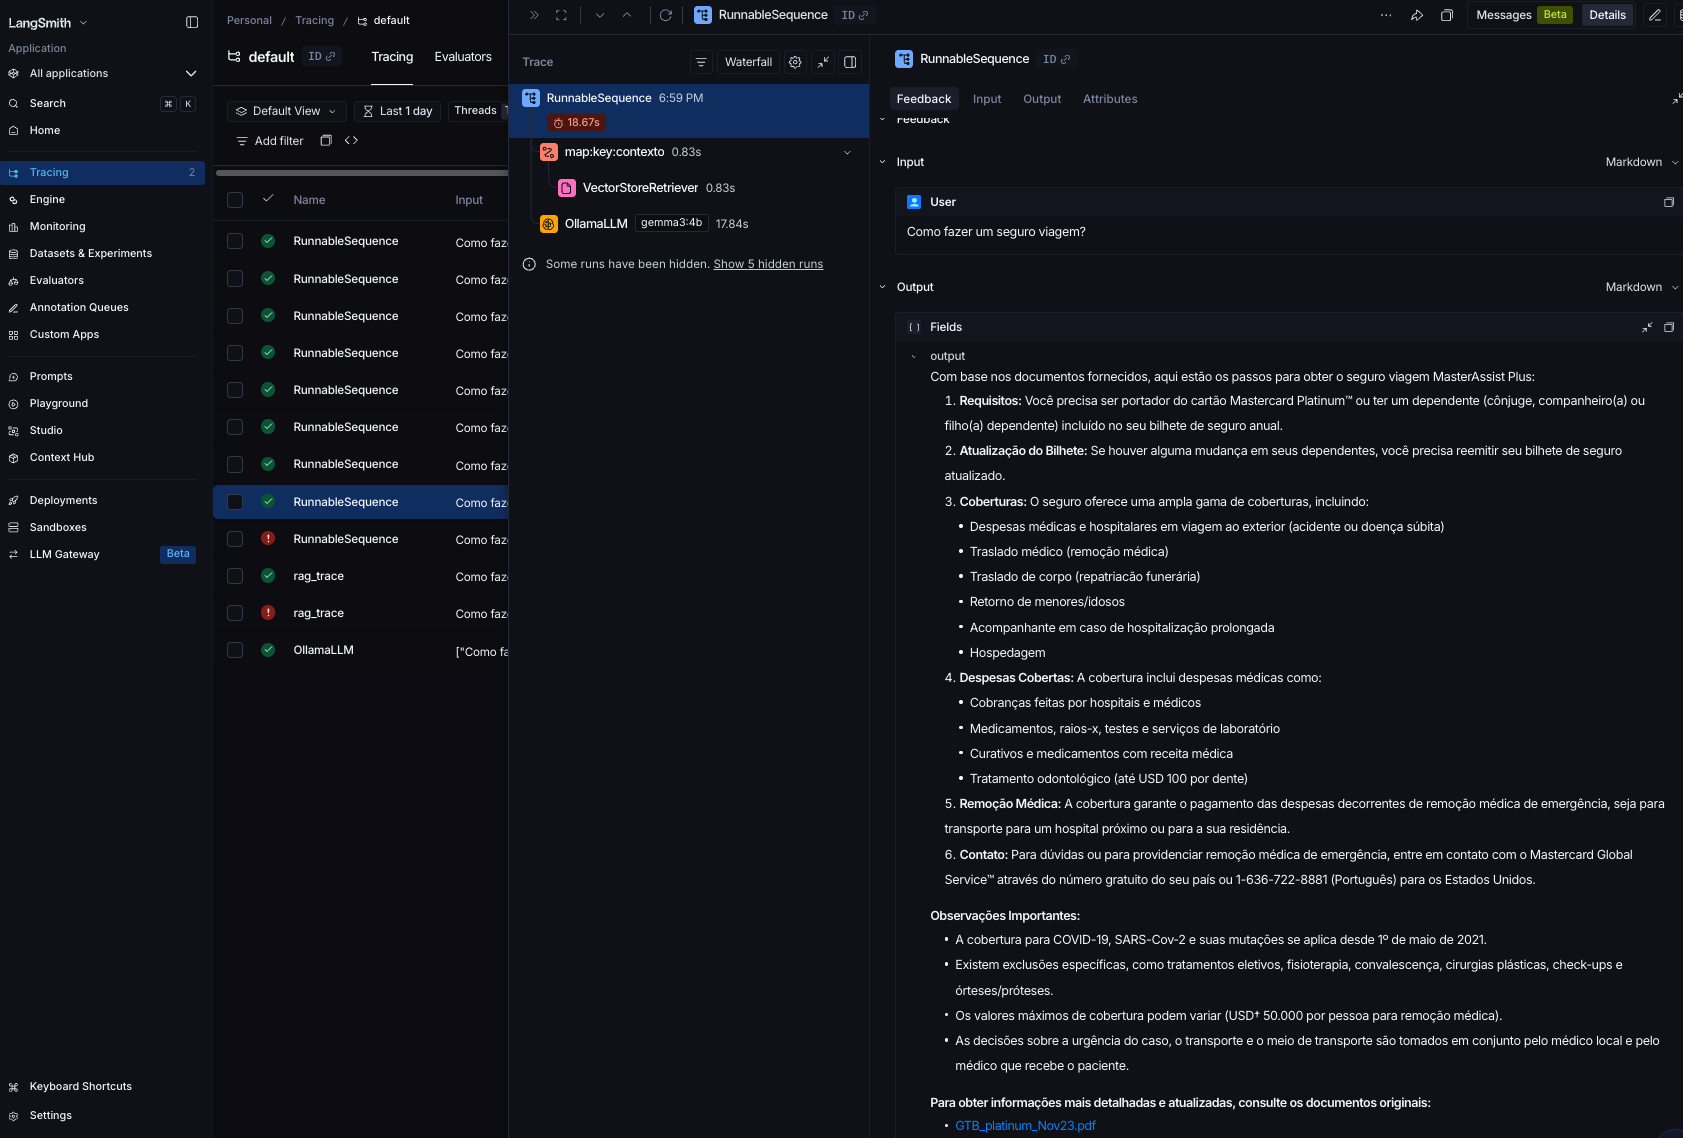

## Question transformations - Rewrite-Retrieve-Read

![image.png](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*wOQsUx-_JRs4zhp7u77Tsw.png)

In [ ]:
# from langchain_core.prompts import PromptTemplate

# query_model = OllamaLLM(model="gemma3:1b")

# pergunta = "Como fazer um seguro viagem?"

# rewriter_prompt_template = """
# Gere consulta de pesquisa para o banco de dados de vetores (Vector DB) a partir de uma pergunta do usuário,
# permitindo uma resposta mais precisa por meio da busca semântica.
# Basta retornar a consulta revisada do Vector DB, entre aspas.

# Pergunta do usuário: {user_question}
# Consulta revisada do Vector DB:
# """

# rewriter_prompt = PromptTemplate.from_template(rewriter_prompt_template)
# rewriter_chain = rewriter_prompt | query_model | StrOutputParser()

# rewriter_chain.invoke(pergunta)

## Resultado da consulta enriquecida usando o modelo Gemma3:1b

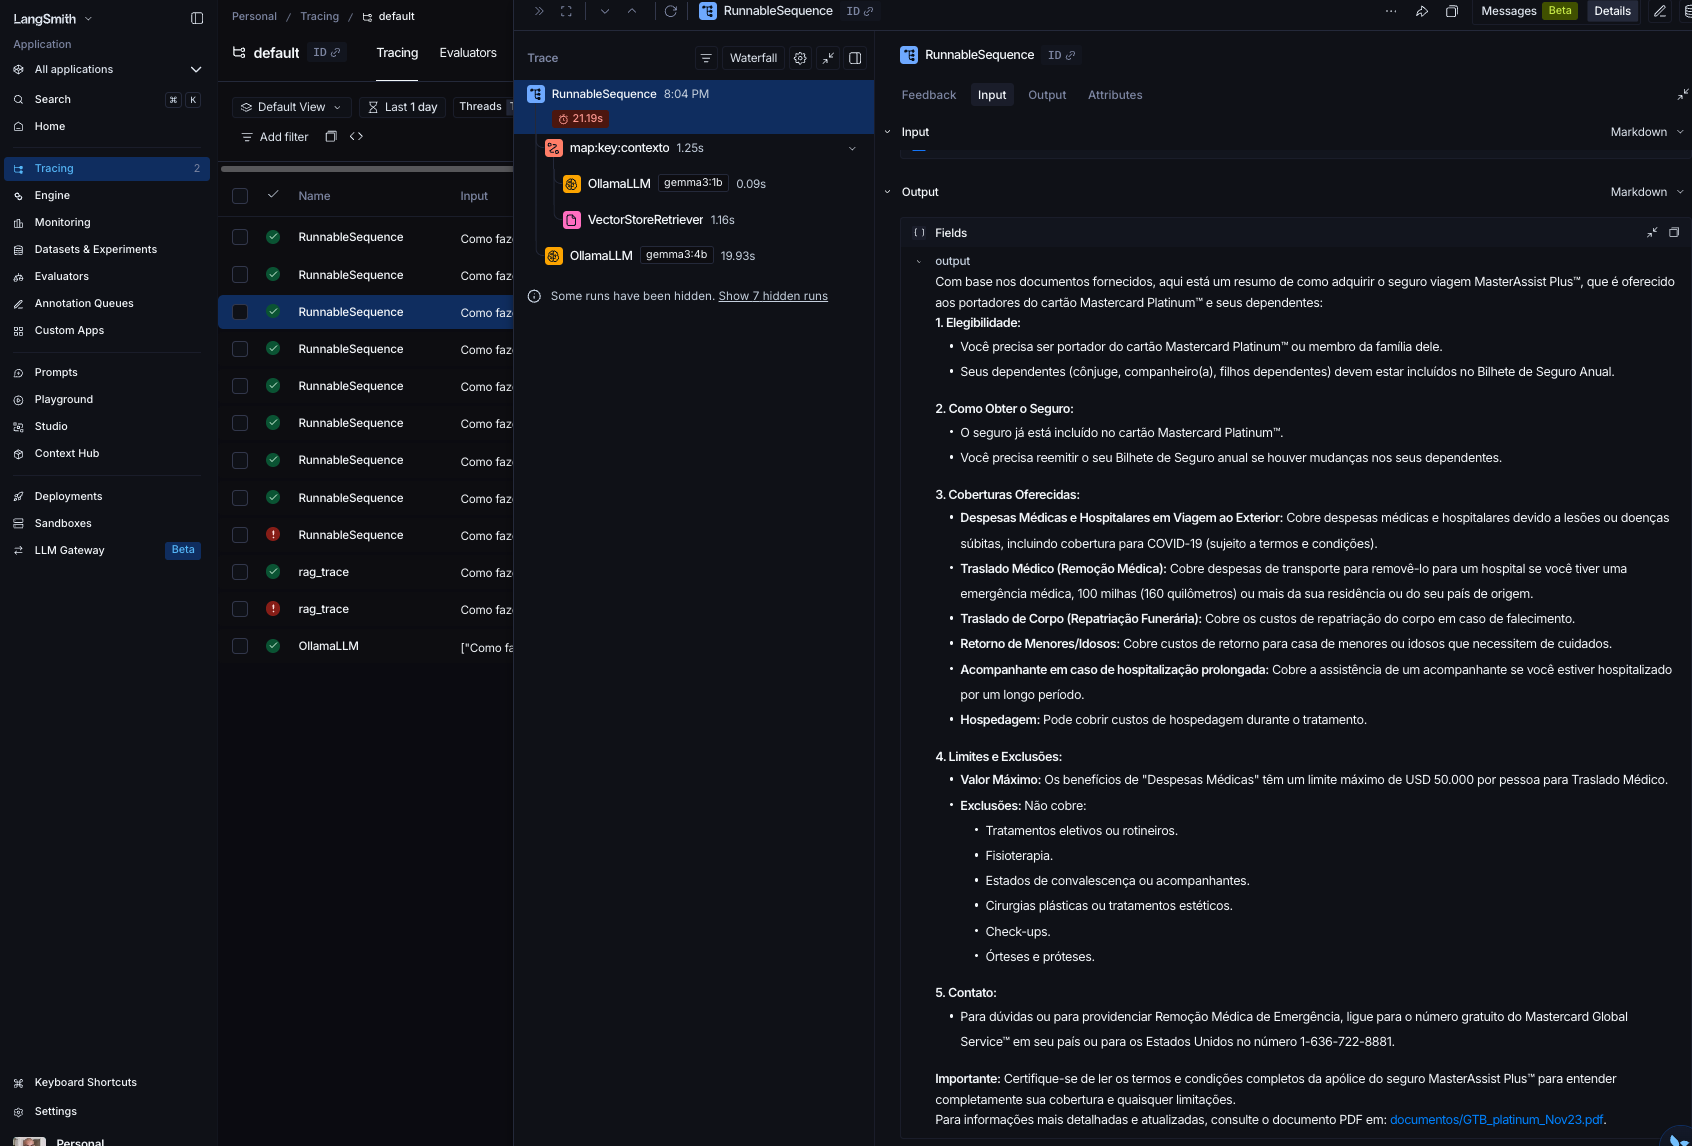

In [22]:
from langchain_core.prompts import PromptTemplate

query_model = OllamaLLM(model="gemma3:1b")

pergunta = "Como fazer um seguro viagem?"

rewriter_prompt_template = """
Gere consulta de pesquisa para o banco de dados de vetores (Vector DB) a partir de uma pergunta do usuário,
permitindo uma resposta mais precisa por meio da busca semântica.
Basta retornar a consulta revisada do Vector DB, entre aspas.

Pergunta do usuário: {user_question}
Consulta revisada do Vector DB:
"""

rewriter_prompt = PromptTemplate.from_template(rewriter_prompt_template)
rewriter_chain = rewriter_prompt | modelo | StrOutputParser()

rewriter_chain.invoke(pergunta)

'"seguro viagem passos como contratar cobertura proteção viagem"\n'

In [23]:
rewriter_rag_chain = (
    {"contexto": RunnablePassthrough()  | rewriter_chain | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [24]:
rewriter_rag_chain.invoke(pergunta)

'Com base no texto fornecido, aqui estão os passos para obter o seguro viagem MasterAssist Plus:\n\n1.  **Cobertura:** O seguro cobre portadores do cartão Mastercard Platinum, seus cônjuges, companheiros e filhos dependentes, viajando juntos ou separados.\n2.  **Limite de Benefício:** O valor máximo de benefício para despesas médicas e hospitalares é de até USD 25.000 por pessoa elegível. Há também limites para traslado médico, prorrogação de estadia, acompanhante e traslado de corpo.\n3.  **Sem Desembolso de Dinheiro:** Pagamentos de despesas médicas podem ser feitos sem necessidade de desembolso de dinheiro, com a Mastercard notificando o hospital ou clínica.\n4.  **Contato:** Para utilizar os serviços, entre em contato com a seção Mastercard Global Service neste guia. O número de telefone para contato é 1-636- 722-7111 (para os EUA).\n\nO texto também destaca que o seguro não é um seguro saúde e é importante ler atentamente as condições contratuais.'

## Resultado da consulta enriquecida usando o modelo Gemma3:4b

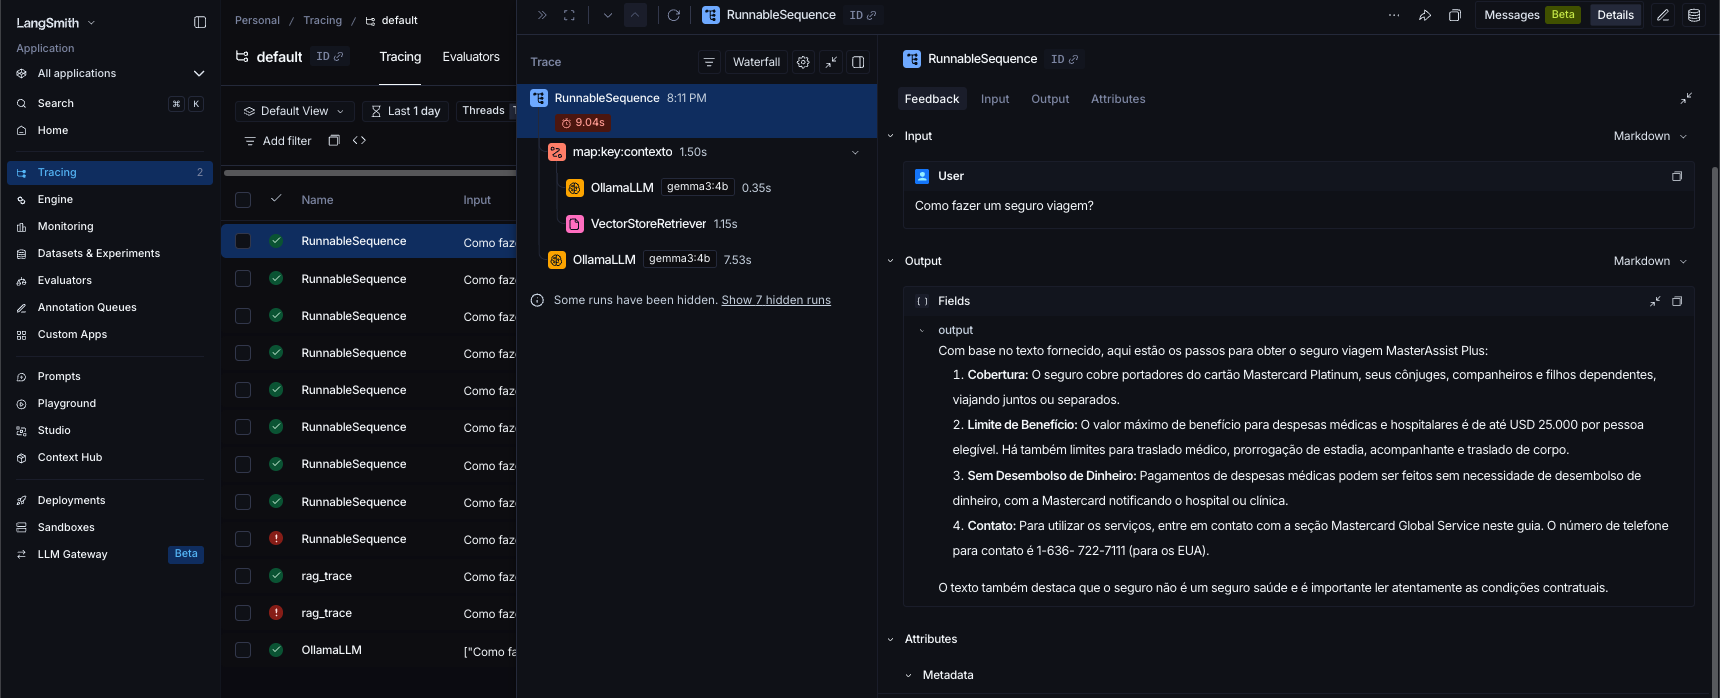

## Generating multiple queries

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*z1EuCfvPHtmISs0dldU1Tw.png)

In [29]:
# Exemplo com modelo Gemma3:4b

from langchain_core.output_parsers import CommaSeparatedListOutputParser
from langchain_openai import ChatOpenAI

multi_query_prompt_template = """Você é um assistente de modelo de linguagem de IA. Sua tarefa é gerar cinco
versões diferentes da pergunta do usuário para recuperar documentos relevantes de um banco de dados vetorial.
Ao gerar múltiplas perspectivas sobre a pergunta do usuário, seu objetivo é ajudar
o usuário a superar algumas das limitações da busca por similaridade baseada em distância.
Forneça estas perguntas alternativas separadas por quebras de linha.
Pergunta original: {question}"""

multi_query_prompt = PromptTemplate.from_template(multi_query_prompt_template)

multi_query_chain = multi_query_prompt | modelo | CommaSeparatedListOutputParser()

print(pergunta)
multi_query_chain.invoke(pergunta)

Como fazer um seguro viagem?


['Aqui estão cinco perguntas alternativas para "Como fazer um seguro viagem?"',
 'projetadas para ajudar a superar algumas das limitações da busca por similaridade baseada em distância:',
 '1.  Quais são os passos envolvidos na aquisição de um seguro de viagem?',
 '2.  O que devo considerar ao escolher um plano de seguro viagem? (Incluindo cobertura',
 'custos e condições)',
 '3.  Processo de compra de seguro viagem: guia completo.',
 '4.  Seguro viagem: requisitos e documentação necessária.',
 '5.  Comparando diferentes tipos de seguro viagem: qual é o melhor para mim?']

In [30]:
# Exemplo com modelo GPT-4.1-nano

from langchain_core.output_parsers import CommaSeparatedListOutputParser
from langchain_openai import ChatOpenAI

openai_api_key = os.getenv("OPENAI_API_KEY")

multi_query_prompt_template = """Você é um assistente de modelo de linguagem de IA. Sua tarefa é gerar cinco
versões diferentes da pergunta do usuário para recuperar documentos relevantes de um banco de dados vetorial.
Ao gerar múltiplas perspectivas sobre a pergunta do usuário, seu objetivo é ajudar
o usuário a superar algumas das limitações da busca por similaridade baseada em distância.
Forneça estas perguntas alternativas separadas por quebras de linha.
Pergunta original: {question}"""

multi_query_prompt = PromptTemplate.from_template(multi_query_prompt_template)

gpt = ChatOpenAI(model="gpt-4.1-nano", temperature=0, api_key=openai_api_key)

multi_query_chain = multi_query_prompt | gpt | CommaSeparatedListOutputParser()

print(pergunta)
multi_query_chain.invoke(pergunta)

Como fazer um seguro viagem?


['Quais são os passos para contratar um seguro viagem?  ',
 'O que devo considerar ao fazer um seguro para viagem internacional?  ',
 'Como posso obter um seguro viagem adequado às minhas necessidades?  ',
 'Quais documentos ou informações são necessários para fazer um seguro viagem?  ',
 'Quais são as principais coberturas oferecidas por um seguro viagem?']

In [36]:
from langchain_classic.retrievers import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever(
    retriever=retriever,
    llm_chain=multi_query_chain
)

multi_rag_chain = (
    {"contexto": RunnablePassthrough()  | multi_query_retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [37]:
multi_rag_chain.invoke(pergunta)

'De acordo com o documento fornecido, para obter a cobertura do seguro viagem, você precisa:\n\n1.  **Iniciar a transação sob seu nome** e pagar todo o depósito de garantia da locadora de automóveis usando seu cartão Mastercard Platinum™.\n2.  **Assinar o Contrato de Locação**.\n\n**Importante:** Não há necessidade de emissão de bilhete de seguro para este benefício. Você estará segurado desde que cumpra os requisitos de elegibilidade.\n\nVocê pode imprimir o resumo dos seus benefícios no site www.aig.com/Mastercard/pt.'

## Resultado da consulta com Multi Query

### 7 documentos retornados
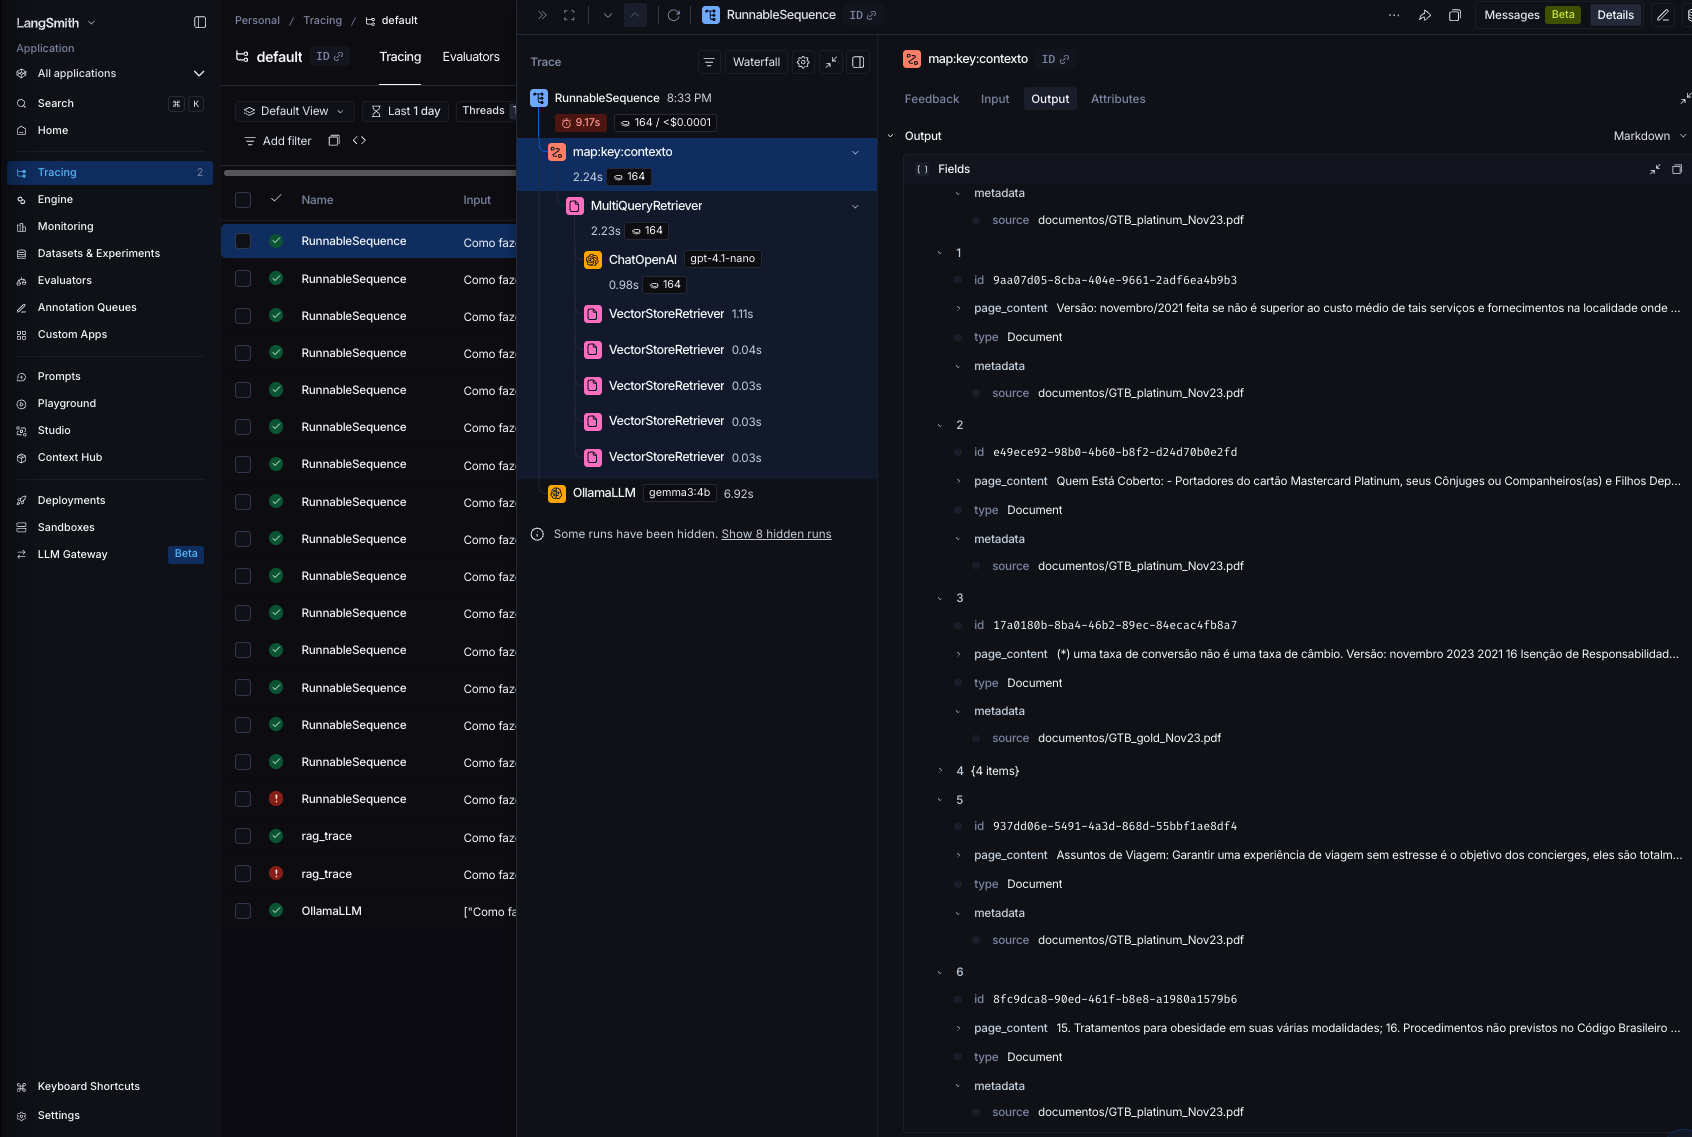

### Output
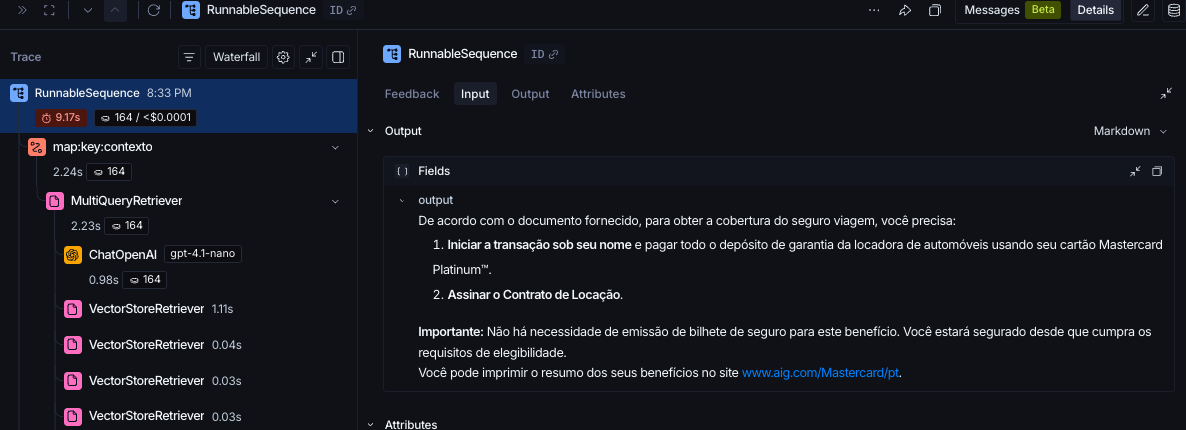

## Hypothetical Document Embeddings (HyDE)

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*akOv9WTwCEdnTgM5VMIi9A.png)

In [38]:
hyde_prompt_template = """
Escreva um paragrafo de até 200 palavras que possa responder à pergunta apresentada. Não adicione mais nada.
Pergunta: {query}
Paragrafo:
"""

hyde_prompt = PromptTemplate.from_template(hyde_prompt_template)

hyde_chain = hyde_prompt | gpt | StrOutputParser()

hyde_chain.invoke(pergunta)

'Para fazer um seguro viagem, primeiro pesquise e compare as opções disponíveis no mercado, levando em consideração cobertura, valores e reputação da seguradora. É importante verificar se o plano inclui assistência médica, odontológica, repatriação, perda de bagagem e cancelamento de viagem. Ao escolher a apólice, leia atentamente as condições gerais e exclusões para evitar surpresas. Após decidir pela melhor opção, preencha o formulário de contratação, fornecendo informações pessoais, detalhes da viagem e cobertura desejada. Geralmente, o pagamento pode ser feito por cartão de crédito ou boleto. Após a confirmação do pagamento, a seguradora enviará o documento do seguro, que deve ser levado durante toda a viagem. Recomenda-se também guardar cópias digitais e físicas do contrato e do cartão de assistência. Além disso, é aconselhável verificar se a sua carteira de identidade ou passaporte estão válidos e se há necessidade de algum documento adicional. Contratar um seguro viagem antes de

## Output do Hyde sem contexto

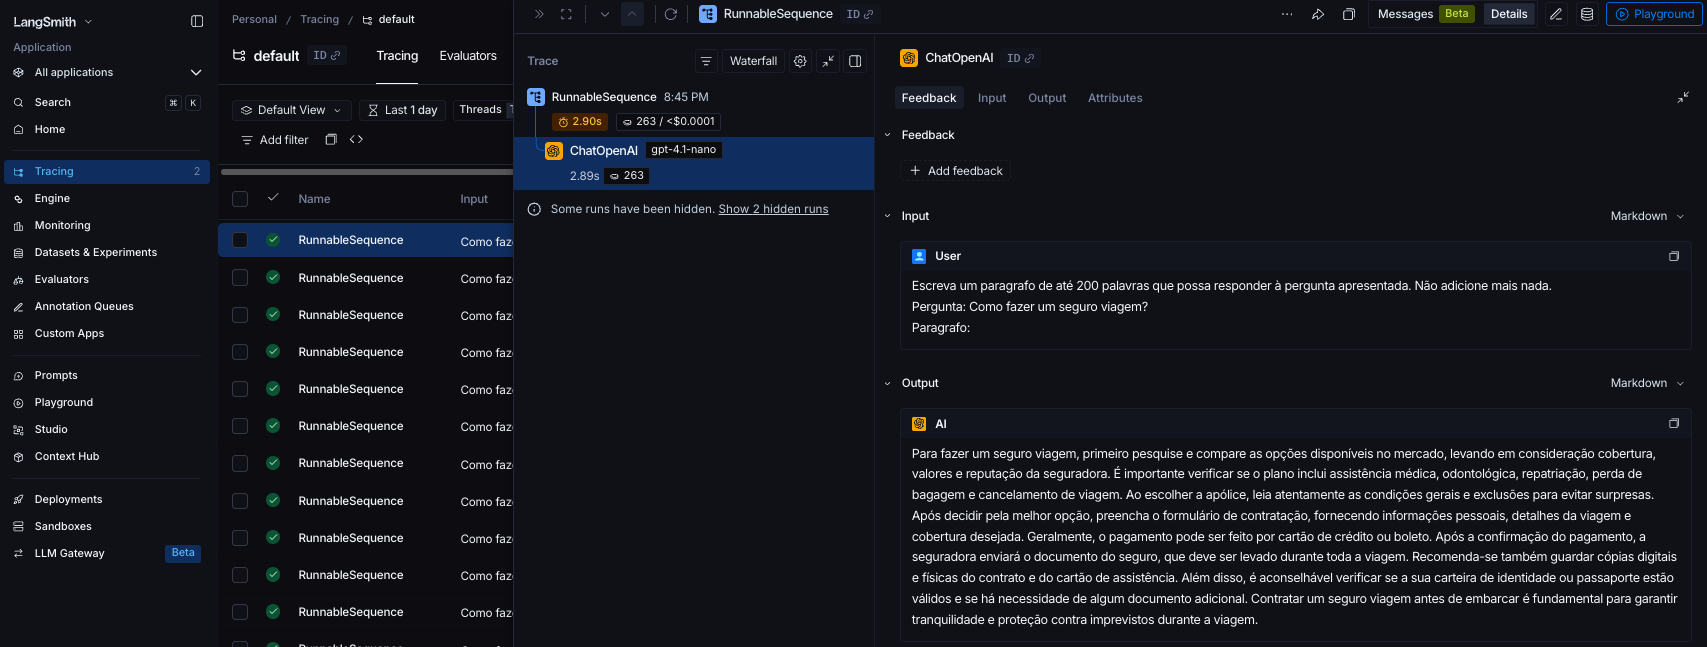

In [39]:
hyde_rag_chain = (
    {"contexto": RunnablePassthrough()  | hyde_chain | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | gpt | StrOutputParser()
)

hyde_rag_chain.invoke(pergunta)

'Para fazer um seguro viagem, é necessário adquirir o Bilhete de Seguro através do portal www.aig.com/Mastercard/pt, que deverá ser apresentado em caso de ocorrência ou sinistro. O bilhete tem validade de 12 meses e cobre viagens de até 31 dias consecutivos. É importante reemitir o bilhete se houver mudanças nos dependentes ou após o período de cobertura.'

## Output do hyde com contexto

### Documento gerado a partir da pergunta
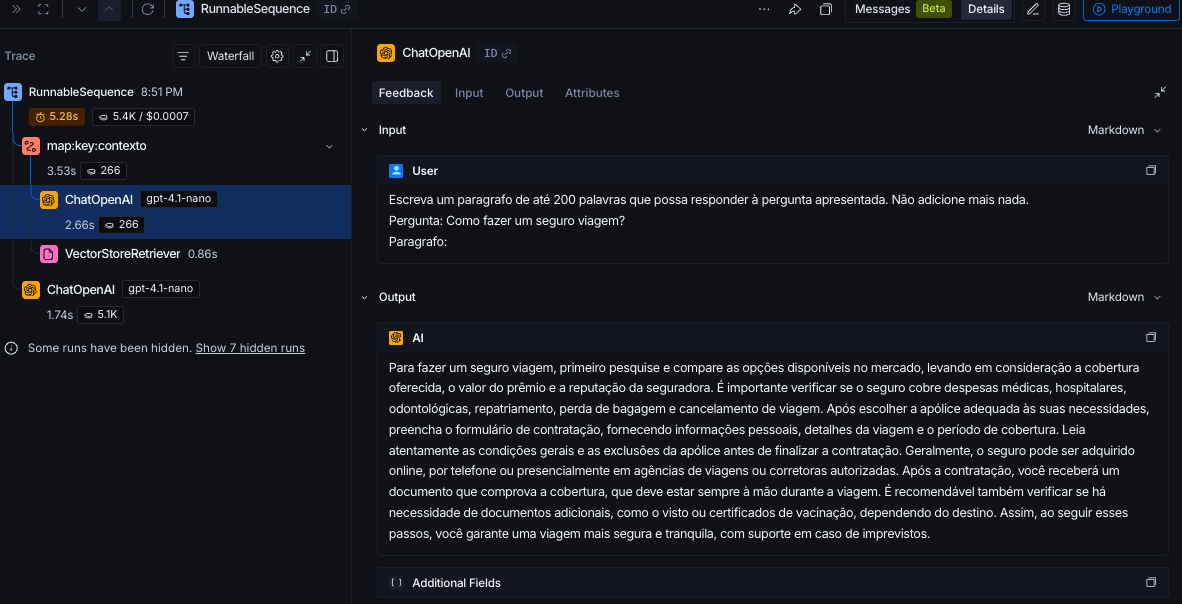

### Documentos retornados na consulta do VectorDB
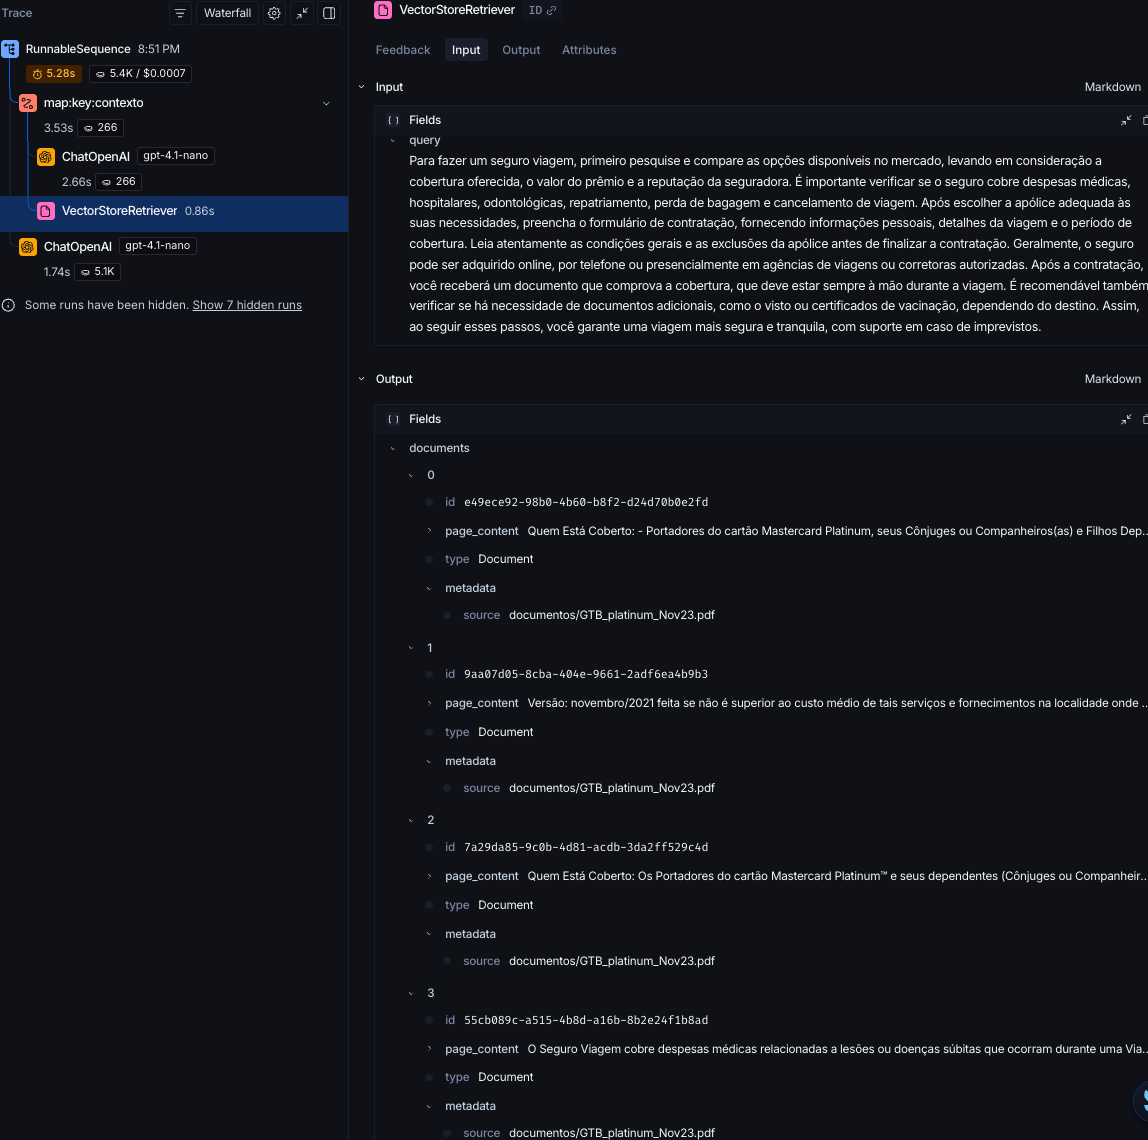

### Output
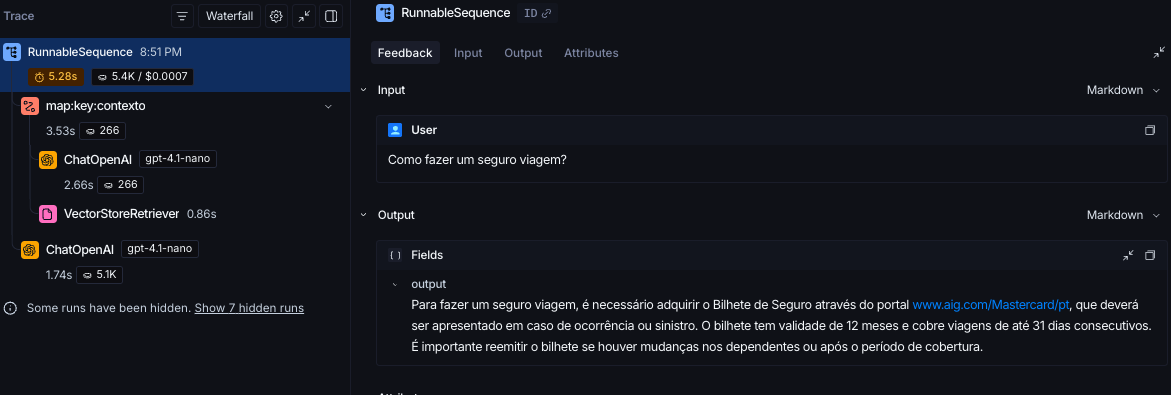
